# Music graph analysis

## Setup

In [2]:
# ────────────────────────────────────────────────────────────────
# Set path
# ────────────────────────────────────────────────────────────────

import sys
import os
from pathlib import Path

# 1) Locate this script (or notebook) directory
try:
    script_dir = Path(__file__).resolve().parent
except NameError:
    # __file__ doesn't exist in notebooks or REPLs
    script_dir = Path.cwd()

# 2) Assume project root is one level up from `python/`
project_root = script_dir.parent

# 3) Sanity check: ensure there's a `data/` folder at the root
if not (project_root / "data").is_dir():
    raise RuntimeError(f"Project root {project_root!r} has no data/ folder.")

# 4) Prepend to sys.path so you can `import` anywhere in Music_Project
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [3]:
# Import packages
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import wikipediaapi
from concurrent.futures import ProcessPoolExecutor, as_completed
from concurrent.futures import ThreadPoolExecutor
import threading
import time
import ast
from collections import Counter, defaultdict

# Load data
df_orig = pd.read_csv(project_root / "data" / "raw" / "originals.csv")
df_cov = pd.read_csv(project_root / "data" / "raw" / "covers.csv")
df_neo = pd.read_csv(project_root / "data" / "raw" / "neo4j_artists.csv")

In [4]:
def write_excel_sheet(path, sheet_name, df, index=True):
    """
    Append df to an Excel workbook, replacing `sheet_name` if it exists.
    Works with pandas >=1.4 (if_sheet_exists) and older versions via openpyxl.
    """
    os.makedirs(os.path.dirname(path), exist_ok=True)

    if os.path.exists(path):
        # Try modern pandas first
        try:
            with pd.ExcelWriter(path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
                df.to_excel(writer, sheet_name=sheet_name, index=index)
            return
        except TypeError:
            # Fallback for pandas < 1.4: delete the sheet first with openpyxl
            from openpyxl import load_workbook
            wb = load_workbook(path)
            if sheet_name in wb.sheetnames:
                del wb[sheet_name]
                wb.save(path)
            mode = "a"
    else:
        mode = "w"

    with pd.ExcelWriter(path, engine="openpyxl", mode=mode) as writer:
        df.to_excel(writer, sheet_name=sheet_name, index=index)

## Wikipedia data collection


In [5]:
# Create dataframe containing only artists with wikipedia links
df_neo_artists = df_neo[['artist_id', 'common_name', 'wiki_url']]
df_neo_artists = df_neo_artists[df_neo_artists['wiki_url'].notna() & (df_neo_artists['wiki_url'] != '')]

# Create dictionaries to map artist ids to names and urls
artist_urls = dict(zip(df_neo_artists['artist_id'], df_neo_artists['wiki_url']))
url_to_artist = {url: id for id, url in artist_urls.items()}
id_to_name = dict(zip(df_neo['artist_id'], df_neo['common_name']))

In [6]:
# Load Wikipedia API
wiki = wikipediaapi.Wikipedia(user_agent="MusicGraphExample (research@example.com)", language="en")

def get_all_links_for_artists(artist_urls, max_workers=10, batch_print=200):
    """
    Run the Wikipedia API calls once, store all linked URLs per artist.
    Returns: dict mapping artist_id -> set of linked artist URLs
    """
    artist_ids = list(artist_urls.keys())
    total = len(artist_ids)
    lock = threading.Lock()
    progress = {'count': 0}
    all_links = {}

    def worker(artist):
        url = artist_urls[artist]
        tries = 3
        for attempt in range(tries):
            try:
                if '/wiki/' not in url:
                    return artist, set()
                page_title = url.split('/wiki/')[-1]
                page = wiki.page(page_title)
                if not page.exists():
                    return artist, set()
                links = page.links.keys()
                full_urls = {f"https://en.wikipedia.org/wiki/{link}" for link in links}
                return artist, full_urls
            except Exception as e:
                if attempt == tries - 1:
                    print(f"Exception in get_page_links for url {url}: {e}")
                    return artist, set()
                else:
                    time.sleep(2 ** attempt)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = executor.map(worker, artist_ids)

        for artist, linked_urls in results:
            with lock:
                progress['count'] += 1
                if progress['count'] % batch_print == 0 or progress['count'] == total:
                    print(f"Processed {progress['count']} / {total} artists...")
            all_links[artist] = linked_urls

    return all_links

# Get linked urls for all artists
all_links = get_all_links_for_artists(artist_urls)

Processed 200 / 5828 artists...
Processed 400 / 5828 artists...
Processed 600 / 5828 artists...
Processed 800 / 5828 artists...
Processed 1000 / 5828 artists...
Processed 1200 / 5828 artists...
Processed 1400 / 5828 artists...
Processed 1600 / 5828 artists...
Processed 1800 / 5828 artists...
Processed 2000 / 5828 artists...
Processed 2200 / 5828 artists...
Processed 2400 / 5828 artists...
Processed 2600 / 5828 artists...
Processed 2800 / 5828 artists...
Processed 3000 / 5828 artists...
Processed 3200 / 5828 artists...
Processed 3400 / 5828 artists...
Processed 3600 / 5828 artists...
Processed 3800 / 5828 artists...
Processed 4000 / 5828 artists...
Processed 4200 / 5828 artists...
Processed 4400 / 5828 artists...
Processed 4600 / 5828 artists...
Processed 4800 / 5828 artists...
Processed 5000 / 5828 artists...
Processed 5200 / 5828 artists...
Processed 5400 / 5828 artists...
Processed 5600 / 5828 artists...
Processed 5800 / 5828 artists...
Processed 5828 / 5828 artists...


## Graph creation


### Wikipedia relations

In [7]:
def build_graph_from_links(all_links, url_to_artist, id_to_name):
    """
    Build the graph using pre-fetched all_links dictionary.

    Directed graph
    Nodes: artists with urls
    Edges artist -> mentioned_artist: mentioned_artist was mentioned in artist's wiki page
    """
    G = nx.DiGraph()
    for artist in all_links.keys():
        G.add_node(artist, name=id_to_name.get(artist, "Unknown"))

    for artist, linked_urls in all_links.items():
        for linked_url in linked_urls:
            if linked_url in url_to_artist and linked_url != artist_urls[artist]:
                mentioned_artist = url_to_artist[linked_url]
                G.add_edge(artist, mentioned_artist, relation={'MENTIONS'})

    print(f"Graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
    return G

# Build graph with wikipedia mentions
G = build_graph_from_links(all_links, url_to_artist, id_to_name)

Graph built with 5828 nodes and 10084 edges.


In [8]:
# Basic stats
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# Count mentions: who is mentioned most (incoming edges)
mention_count = Counter(v for _, v in G.edges())
top10 = mention_count.most_common(10)

print("Top-10 most-mentioned artists:")
for name, cnt in top10:
    print(f"{G.nodes[name]['name']}: mentioned by {cnt} pages")

Nodes: 5828
Edges: 10084
Top-10 most-mentioned artists:
Adele: mentioned by 389 pages
Beyoncé: mentioned by 373 pages
U2: mentioned by 361 pages
Eminem: mentioned by 316 pages
Madonna: mentioned by 313 pages
Metallica: mentioned by 255 pages
Aerosmith: mentioned by 242 pages
Coldplay: mentioned by 241 pages
Rihanna: mentioned by 240 pages
Bono: mentioned by 225 pages


### Genre property

In [9]:
# 1) Read in your full artist CSV
path = project_root/"data/scraping/genre/artist_genres.csv"
df_genres = pd.read_csv(path)

# 2) Collect the genre columns into a list, dropping empties/NaNs
genre_cols = [f"genre_{i}" for i in range(1, 14)]
df_genres["genres"] = (
    df_genres[genre_cols]
      .apply(lambda row: [g for g in row if pd.notna(g) and g != ""], axis=1)
)

# 3) Index by the same artist key you use in G (artist_id)
df_genres.set_index("artist_id", inplace=True)

# 4) Attach the genres list as a property to each node in G
for artist in G.nodes():
    if artist in df_genres.index:
        G.nodes[artist]["genres"] = df_genres.at[artist, "genres"]
    else:
        G.nodes[artist]["genres"] = []

# 5) Verify on a few nodes
for artist in list(G.nodes())[:5]:
    print(G.nodes[artist]['name'], "→", G.nodes[artist]["genres"])

Van Morrison → ['r&b & soul', 'world', 'rock', 'electronic', 'folk', 'blues / country', 'jazz', 'other', 'pop']
Dinah Washington → ['jazz', 'blues / country', 'electronic', 'other', 'pop']
Aretha Franklin → ['r&b & soul', 'electronic', 'other', 'jazz', 'pop']
Marie Fredriksson → ['rock']
The Beach Boys → ['rock', 'pop']


In [10]:
def flatten_genres(genres):
    """Flatten nested lists in genres into a single-level list of strings."""
    flat = []
    if genres is None:
        return flat
    for g in genres:
        if isinstance(g, list):
            flat.extend(g)
        else:
            flat.append(g)
    # Optionally convert everything to str (if needed)
    flat = [str(x) for x in flat]
    return flat

for node in G.nodes():
    genres = G.nodes[node].get('genres', [])
    G.nodes[node]['genres'] = flatten_genres(genres)


# Verify on a few nodes
for artist in list(G.nodes())[:5]:
    print(G.nodes[artist]['name'], "→", G.nodes[artist]["genres"])

Van Morrison → ['r&b & soul', 'world', 'rock', 'electronic', 'folk', 'blues / country', 'jazz', 'other', 'pop']
Dinah Washington → ['jazz', 'blues / country', 'electronic', 'other', 'pop']
Aretha Franklin → ['r&b & soul', 'electronic', 'other', 'jazz', 'pop']
Marie Fredriksson → ['rock']
The Beach Boys → ['rock', 'pop']


next code cell can probably be deleted

In [11]:
rock_edges_both = [
    (u, v)
    for u, v in G.edges()
    if 'rock' in G.nodes[u].get('genres', []) and
       'rock' in G.nodes[v].get('genres', [])
]

rock_nodes_both = {n for edge in rock_edges_both for n in edge}

print(f"Number of nodes in 'rock ↔ rock' edges: {len(rock_nodes_both)}")
print("Nodes:", rock_nodes_both)

Number of nodes in 'rock ↔ rock' edges: 1333
Nodes: {24576, 6, 65543, 11, 14, 16, 17, 16401, 20, 28, 24608, 33, 24609, 35, 24611, 8229, 41, 42, 45, 48, 49, 32819, 52, 53, 54, 57, 57409, 69, 73, 75, 76, 32847, 8273, 8274, 41044, 85, 88, 90, 24666, 96, 100, 101, 32870, 103, 65639, 105, 24683, 116, 119, 128, 134, 8337, 150, 152, 155, 156, 24733, 158, 162, 167, 169, 32937, 171, 16569, 187, 191, 193, 198, 201, 204, 205, 211, 212, 73941, 214, 223, 41184, 41185, 227, 229, 230, 233, 33002, 240, 49400, 41208, 8445, 98562, 259, 260, 269, 281, 282, 24857, 8476, 24858, 65818, 291, 293, 294, 297, 298, 8489, 8491, 8492, 8493, 303, 306, 307, 24885, 98628, 326, 334, 65872, 347, 354, 361, 372, 374, 375, 49527, 377, 378, 8569, 382, 387, 391, 394, 8587, 402, 49565, 16802, 33187, 423, 8636, 33216, 451, 41415, 457, 41424, 16852, 8661, 33240, 41443, 484, 8690, 512, 74241, 90624, 515, 524, 526, 527, 74258, 533, 535, 25112, 537, 25113, 543, 545, 556, 557, 559, 25147, 8764, 8765, 584, 33358, 33359, 597, 600, 6

### Cover relations

In [12]:
# Merge on org_perf_id column in df_cov and perf_id in df_orig, keep only cov_art_id and org_art_id 
# Not merging on song title because songs can have the same names
df_merged = pd.merge(
    df_cov[['org_perf_id', 'cov_art_id']],
    df_orig[['perf_id', 'org_art_id']],
    left_on='org_perf_id',
    right_on='perf_id',
    how='inner'
)[['cov_art_id', 'org_art_id']]

print(df_merged.head())
print(df_merged.shape)

  cov_art_id org_art_id
0      [879]        [1]
1   [5, 237]     [5483]
2        [7]        [6]
3       [10]        [8]
4        [9]        [8]
(367622, 2)


In [13]:
# Step 1: Parse stringified lists if needed
def parse_list(val):
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return [val]
    return val

df_merged['cov_art_id'] = df_merged['cov_art_id'].apply(parse_list)
df_merged['org_art_id'] = df_merged['org_art_id'].apply(parse_list)

# Step 2: Explode both columns
df_exploded = df_merged.explode('cov_art_id').explode('org_art_id').reset_index(drop=True)
print(df_exploded)

       cov_art_id org_art_id
0             879          1
1               5       5483
2             237       5483
3               7          6
4              10          8
...           ...        ...
482896      64925      11276
482897      35611      17062
482898      14339       2437
482899      14339      69125
482900        894       1389

[482901 rows x 2 columns]


In [14]:
edge_count = 0
for _, row in df_merged.iterrows():
    covering_artists = row['cov_art_id']
    original_artists = row['org_art_id']

    # Create edges for every pair (covering -> original)
    for cov_id in covering_artists:
        for org_id in original_artists:
            if cov_id != org_id: # avoid self-loop #and cov_id in G and org_id in G:
                
                # Ensure nodes exist with name attributes
                if cov_id not in G:
                    G.add_node(cov_id, name=id_to_name.get(cov_id, "Unknown"))
                if org_id not in G:
                    G.add_node(org_id, name=id_to_name.get(org_id, "Unknown"))

                # If edge exists, add weight to it 
                if G.has_edge(cov_id, org_id):
                    edge_data = G[cov_id][org_id]
                    edge_data.setdefault('relation', set()).add('COVERED')
                    edge_data['weight'] = edge_data.get('weight', 0) + 1

                # If edge does not exist yet, create edge
                else:
                    G.add_edge(cov_id, org_id, relation={'COVERED'}, weight=1)
                edge_count += 1

In [15]:
# Check if weights are added correctly 
u, v, data = max(G.edges(data=True), key=lambda x: x[2].get('weight', 0))
print(f"Edge with highest weight: {u} → {v}")
print("  Names:", G.nodes[u].get('name', 'Unknown'), "→", G.nodes[v].get('name', 'Unknown'))
print("  Relation:", data.get('relation'))
print("  Weight:", data.get('weight'))

Edge with highest weight: 97325 → 41
  Names: The Coverbeats → The Beatles
  Relation: {'COVERED'}
  Weight: 135


In [16]:
# Basic stats
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# Count how many times each artist is covered
cover_count = Counter()

for u, v, data in G.edges(data=True):
    if 'COVERED' in data.get('relation', []):
        cover_count[v] += 1  # v = original artist who was covered

# Get top 10 most covered artists
top_10_covered = cover_count.most_common(10)

# Create the DataFrame
covered_top_10 = pd.DataFrame(
    [(artist, G.nodes[artist]['name'], count) for artist, count in top_10_covered],
    columns=['artist_id', 'artist_name', 'cover_count']
)

covered_top_10

Nodes: 65833
Edges: 414104


,artist_id,artist_name,cover_count
0,41,The Beatles,4448
1,4305,Duke Ellington,2450
2,243,Bing Crosby,2413
3,158,Bob Dylan,1908
4,2232,Fred Astaire,1841
5,319,Frank Sinatra,1654
6,2223,Abbie Mitchell,1590
7,1424,Judy Garland,1550
8,5773,Joseph Mohr,1437
9,5774,Franz Gruber,1437


### Sub-graph creation (cover network vs. wiki network)

In [17]:
# Create covered-only subgraph (with weights)
edges_covered = [(u, v) for u, v, d in G.edges(data=True) if 'COVERED' in d.get('relation', set())]
G_covered = G.edge_subgraph(edges_covered).copy()

# Basic stats
print("Nodes:", G_covered.number_of_nodes())
print("Edges:", G_covered.number_of_edges())

Nodes: 64361
Edges: 404317


In [18]:
# Create mentioned-only subgraph (no weights)
edges_mentions = [(u, v) for u, v, d in G.edges(data=True) if 'MENTIONS' in d.get('relation', set())]
G_mentions = G.edge_subgraph(edges_mentions).copy()

# Basic stats
print("Nodes:", G_mentions.number_of_nodes())
print("Edges:", G_mentions.number_of_edges())

Nodes: 2809
Edges: 10084


### Sub-graph creation (cross & within genre network)

#### Set rule to distinct between cross & within genre

In [19]:
# Central helper used across genre analyses (genre impact, cross-PR, etc.)
def genres_similar(genres1, genres2, threshold=0.5):
    """Return True if genre lists are similar under a guarded overlap rule.

    Rule:
    - overlap_ratio = |A ∩ B| / max(|A|, |B|)
    - If max(|A|, |B|) >= 3, also require at least 2 shared tags (small guard for long lists).
    """
    def _clean(gen_list):
        if not gen_list:
            return set()
        out = set()
        for g in gen_list:
            if g is None:
                continue
            s = str(g).strip().casefold()
            if not s:
                continue
            out.add(s)
        return out

    set1, set2 = _clean(genres1), _clean(genres2)
    if not set1 or not set2:
        return False

    overlap = len(set1 & set2)
    max_len = max(len(set1), len(set2))

    # Small guard for long lists: need at least 2 shared tags when either side has >= 3
    min_common = 2 if max_len >= 3 else 1

    overlap_ratio = overlap / max_len
    return (overlap >= min_common) and (overlap_ratio >= threshold)

# Global similarity threshold used throughout
_similarity_threshold = 0.5

In [20]:
# Build within-genre and cross-genre subgraphs 

# Collect edges where both endpoints have genres and pass the guarded rule
edges_within = []
edges_cross  = []

for u, v, d in G_covered.edges(data=True):
    gu = G_covered.nodes[u].get('genres', [])
    gv = G_covered.nodes[v].get('genres', [])
    if not gu or not gv:
        continue  # skip edges with missing genre info
    if genres_similar(gu, gv, threshold=_similarity_threshold):
        edges_within.append((u, v))
    else:
        edges_cross.append((u, v))

# Create edge-induced subgraphs (keeps edge attributes like 'weight')
G_within = G_covered.edge_subgraph(edges_within).copy()
G_cross  = G_covered.edge_subgraph(edges_cross).copy()

# Basic stats
print("WITHIN-GENRE subgraph")
print("  Nodes:", G_within.number_of_nodes())
print("  Edges:", G_within.number_of_edges())

print("\nCROSS-GENRE subgraph")
print("  Nodes:", G_cross.number_of_nodes())
print("  Edges:", G_cross.number_of_edges())

WITHIN-GENRE subgraph
  Nodes: 2731
  Edges: 8068

CROSS-GENRE subgraph
  Nodes: 3200
  Edges: 13525


Split info: {'m_total': 404317, 'm_valid': 21593, 'skipped_missing': 382724}
WITHIN: nodes 2731 edges 8068
CROSS:  nodes 3200 edges 13525
                                   Metric     Value
             Number of vertices (artists)      2731
            Number of edges (song covers)      8068
                     Number of components        37
Average shortest path length (largest CC)       N/A
                                  Density  0.001082
                                   Metric     Value
             Number of vertices (artists)      3200
            Number of edges (song covers)     13525
                     Number of components        12
Average shortest path length (largest CC)       N/A
                                  Density  0.001321
                                   Metric     Value
             Number of vertices (artists)     64361
            Number of edges (song covers)    404317
                     Number of components       189
Average shortest path length (

## Network description

### Total network

In [21]:
def compute_graph_metrics(G):
    """
    Compute basic graph metrics for a directed or undirected NetworkX graph.
    Uses largest weakly connected component for shortest path calculation.
    """

    # Basic stats
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    density = nx.density(G)

    # Components (weakly connected components for directed graph)
    num_components = nx.number_weakly_connected_components(G)

    # Average shortest path length (largest weakly connected component)
    largest_cc = max(nx.weakly_connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc)
    try:
        avg_shortest_path = nx.average_shortest_path_length(G_sub)
    except:
        avg_shortest_path = "N/A (graph not connected)"

    # Create DataFrame
    metrics = {
        "Metric": [
            "Number of vertices (artists)",
            "Number of edges (song covers)",
            "Number of components",
            "Average shortest path length",
            "Density"
        ],
        "Value": [
            num_nodes,
            num_edges,
            num_components,
            avg_shortest_path,
            density
        ]
    }

    return pd.DataFrame(metrics)

In [22]:
# Description of total network
total_metrics_df = compute_graph_metrics(G)
total_metrics_df

,Metric,Value
0,Number of vertices (artists),65833
1,Number of edges (song covers),414104
2,Number of components,1116
3,Average shortest path length,N/A (graph not connected)
4,Density,0.000096


### Cover network

In [23]:
# Description of cover subgraph
cover_metrics_df = compute_graph_metrics(G_covered)
cover_metrics_df

,Metric,Value
0,Number of vertices (artists),64361
1,Number of edges (song covers),404317
2,Number of components,189
3,Average shortest path length,N/A (graph not connected)
4,Density,0.000098


### Wiki relation network

In [24]:
# Description of wiki subgraph
wiki_metrics_df = compute_graph_metrics(G_mentions)
wiki_metrics_df

,Metric,Value
0,Number of vertices (artists),2809
1,Number of edges (song covers),10084
2,Number of components,12
3,Average shortest path length,N/A (graph not connected)
4,Density,0.001278


### Genre Network

In [72]:
import networkx as nx
import pandas as pd
from math import inf

# --- Robust within/cross builders (handles DiGraph and MultiDiGraph) ---
def make_within_cross_subgraphs(G, threshold=0.5, keep_all_nodes=False):
    is_multi = G.is_multigraph()

    # Partition edges
    if is_multi:
        edges_iter = G.edges(keys=True, data=True)  # (u, v, k, d)
    else:
        edges_iter = G.edges(data=True)             # (u, v, d)

    within_edges = []
    cross_edges  = []
    skipped_missing = 0

    for e in edges_iter:
        if is_multi:
            u, v, k, d = e
        else:
            u, v, d = e

        gu = G.nodes[u].get('genres', [])
        gv = G.nodes[v].get('genres', [])
        if not gu or not gv:
            skipped_missing += 1
            continue

        if genres_similar(gu, gv, threshold=threshold):
            within_edges.append((u, v, k) if is_multi else (u, v))
        else:
            cross_edges.append((u, v, k) if is_multi else (u, v))

    # Edge-induced subgraphs (preserve attributes/keys)
    G_within = G.edge_subgraph(within_edges).copy()
    G_cross  = G.edge_subgraph(cross_edges).copy()

    if keep_all_nodes:
        # Re-add isolates from the base graph (for centrality normalization if desired)
        def add_all_nodes(base, sub):
            H = nx.MultiDiGraph() if base.is_multigraph() else nx.DiGraph()
            H.add_nodes_from(base.nodes(data=True))
            H.add_edges_from(sub.edges(data=True, keys=True) if base.is_multigraph() else sub.edges(data=True))
            return H
        G_within = add_all_nodes(G, G_within)
        G_cross  = add_all_nodes(G, G_cross)

    # Sanity check counts (edges with both endpoints tagged should split into within+cross)
    if G.is_multigraph():
        m_total = G.number_of_edges()
        m_valid = sum(1 for u, v, k, d in G.edges(keys=True, data=True)
                      if G.nodes[u].get('genres') and G.nodes[v].get('genres'))
    else:
        m_total = G.number_of_edges()
        m_valid = sum(1 for u, v, d in G.edges(data=True)
                      if G.nodes[u].get('genres') and G.nodes[v].get('genres'))

    assert G_within.number_of_edges() + G_cross.number_of_edges() == m_valid, \
        f"Edge split mismatch: within({G_within.number_of_edges()}) + cross({G_cross.number_of_edges()}) != valid({m_valid}). " \
        f"Skipped for missing genres: {skipped_missing}. Total in G: {m_total}"

    return G_within, G_cross, {'m_total': m_total, 'm_valid': m_valid, 'skipped_missing': skipped_missing}

# --- Consistent graph metrics (directed vs undirected handled) ---
def compute_graph_metrics(G):
    """
    Basic stats for directed or undirected NetworkX graphs.
    Shortest-path length is computed on the largest connected component:
      - weakly connected for DiGraph/MultiDiGraph
      - connected for Graph/MultiGraph
    """
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    density   = nx.density(G)

    if G.is_directed():
        num_components = nx.number_weakly_connected_components(G)
        largest_cc_nodes = max(nx.weakly_connected_components(G), key=len) if num_nodes else set()
        G_sub = G.subgraph(largest_cc_nodes).copy()
    else:
        num_components = nx.number_connected_components(G)
        largest_cc_nodes = max(nx.connected_components(G), key=len) if num_nodes else set()
        G_sub = G.subgraph(largest_cc_nodes).copy()

    try:
        avg_shortest_path = nx.average_shortest_path_length(G_sub) if G_sub.number_of_nodes() > 1 else 0.0
    except Exception:
        avg_shortest_path = "N/A"

    return pd.DataFrame({
        "Metric": [
            "Number of vertices (artists)",
            "Number of edges (song covers)",
            "Number of components",
            "Average shortest path length (largest CC)",
            "Density"
        ],
        "Value": [
            num_nodes,
            num_edges,
            num_components,
            avg_shortest_path,
            density
        ]
    })

# --- How to use (and verify counts) ---
# Build once, reuse everywhere
G_within, G_cross, split_info = make_within_cross_subgraphs(
    G_covered, threshold=_similarity_threshold, keep_all_nodes=False
)
print("Split info:", split_info)
print("WITHIN: nodes", G_within.number_of_nodes(), "edges", G_within.number_of_edges())
print("CROSS:  nodes", G_cross.number_of_nodes(),  "edges", G_cross.number_of_edges())

# Now metrics will match because you're passing the exact graphs
within_metrics_df = compute_graph_metrics(G_within)
cross_metrics_df  = compute_graph_metrics(G_cross)
covered_metrics_df = compute_graph_metrics(G_covered)
print(within_metrics_df.to_string(index=False))
print(cross_metrics_df.to_string(index=False))
print(covered_metrics_df.to_string(index=False))

Split info: {'m_total': 404317, 'm_valid': 21593, 'skipped_missing': 382724}
WITHIN: nodes 2731 edges 8068
CROSS:  nodes 3200 edges 13525
                                   Metric     Value
             Number of vertices (artists)      2731
            Number of edges (song covers)      8068
                     Number of components        37
Average shortest path length (largest CC)       N/A
                                  Density  0.001082
                                   Metric     Value
             Number of vertices (artists)      3200
            Number of edges (song covers)     13525
                     Number of components        12
Average shortest path length (largest CC)       N/A
                                  Density  0.001321
                                   Metric     Value
             Number of vertices (artists)     64361
            Number of edges (song covers)    404317
                     Number of components       189
Average shortest path length (

## Centrality metrics

### Centrality metrics on cover network

In [27]:
def top_metric_df(metric_scores, graph, score_name, top_n=10):
    """
    Create a DataFrame of the top N nodes for a given metric.

    Parameters
    ----------
    metric_scores : dict
        Dictionary mapping node IDs to metric scores.
    graph : networkx.Graph
        The graph containing the nodes and their attributes.
    score_name : str
        The name of the metric column in the output DataFrame.
    top_n : int, optional
        Number of top nodes to select (default is 10).

    Returns
    -------
    pd.DataFrame
        DataFrame with columns: artist_id, artist_name, <score_name>.
    """
    top_nodes = sorted(metric_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return pd.DataFrame({
        'artist_id': [node for node, _ in top_nodes],
        'artist_name': [graph.nodes[node].get('name', 'Unknown') for node, _ in top_nodes],
        score_name: [score for _, score in top_nodes]
    })

In [28]:
# In-degree centrality
in_deg_cov_scores = nx.in_degree_centrality(G_covered)
in_deg_cov_df = top_metric_df(in_deg_cov_scores, G_covered, 'in_degree_centrality')
in_deg_cov_df.round(4)

,artist_id,artist_name,in_degree_centrality
0,41,The Beatles,0.0691
1,4305,Duke Ellington,0.0381
2,243,Bing Crosby,0.0375
3,158,Bob Dylan,0.0296
4,2232,Fred Astaire,0.0286
5,319,Frank Sinatra,0.0257
6,2223,Abbie Mitchell,0.0247
7,1424,Judy Garland,0.0241
8,5773,Joseph Mohr,0.0223
9,5774,Franz Gruber,0.0223


In [57]:
# Save results to Excel file
within_path = os.path.join(project_root, "data", "results", "cover.xlsx")
write_excel_sheet(within_path, "in_degree", in_deg_cov_df, index=True)

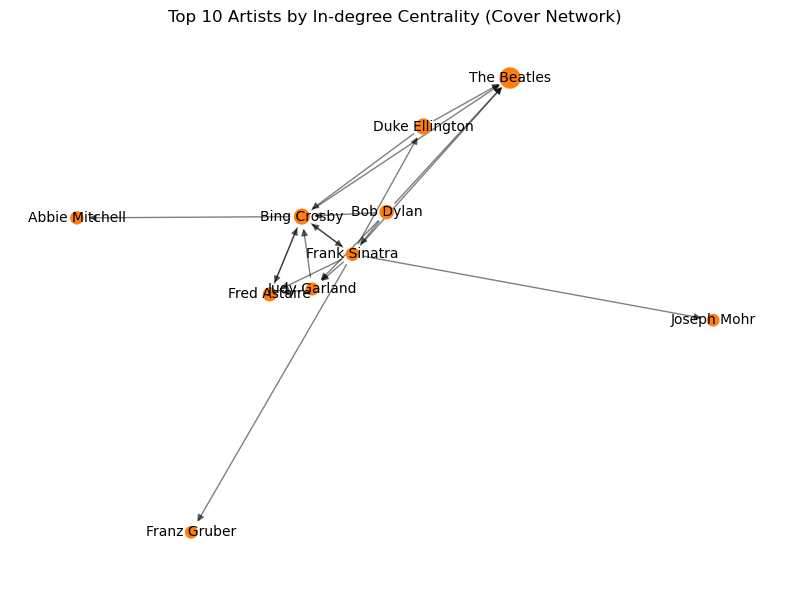

In [27]:
# Visualize only the top 10 in-degree centrality nodes and their edges in the cover network

# Get top 10 artist IDs by in-degree centrality
top_nodes = in_deg_cov_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_covered.subgraph(top_nodes).copy()

# Node colors: all orange
node_colors = ["#ff7f0e"] * len(G_top10.nodes())

# Node sizes: scale by in-degree centrality (optional, for visual effect)
sizes = [in_deg_cov_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by In-degree Centrality (Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [30]:
# PageRank (weighted)
pagerank_cov_scores = nx.pagerank(G_covered, alpha=0.85, weight='weight')
pagerank_cov_df = top_metric_df(pagerank_cov_scores, G_covered, 'pagerank_score')
pagerank_cov_df.round(4)

,artist_id,artist_name,pagerank_score
0,41,The Beatles,0.0129
1,158,Bob Dylan,0.0058
2,243,Bing Crosby,0.0036
3,616,Depeche Mode,0.0034
4,327,Chuck Berry,0.0034
5,4305,Duke Ellington,0.0034
6,206,The Rolling Stones,0.0033
7,26565,Prince's Band,0.0031
8,90,The Velvet Underground,0.0029
9,1886,Hank Williams,0.0028


In [58]:
# Save to Excel file
within_path = os.path.join(project_root, "data", "results", "cover.xlsx")
write_excel_sheet(within_path, "PageRank", pagerank_cov_df, index=True)

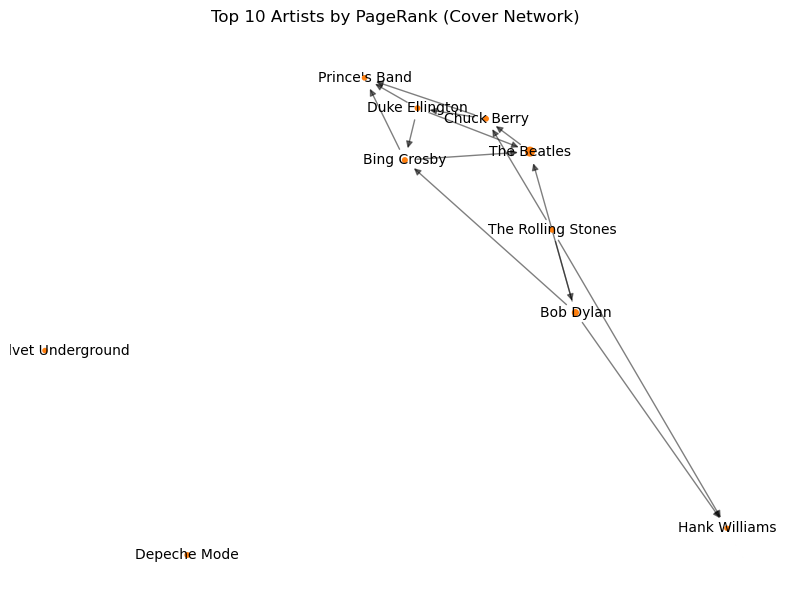

In [29]:
# Visualize only the top 10 PageRank (weighted) nodes and their edges in the cover network

# Get top 10 artist IDs by PageRank
top_nodes = pagerank_cov_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_covered.subgraph(top_nodes).copy()

# Node colors: all orange
node_colors = ["#ff7f0e"] * len(G_top10.nodes())

# Node sizes: scale by PageRank score (for visual effect)
sizes = [pagerank_cov_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by PageRank (Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [32]:
# Betweenness centrality
betweenness_cov_scores = nx.betweenness_centrality(G_covered, k=100, seed=13)
betweenness_cov_df = top_metric_df(betweenness_cov_scores, G_covered, 'betweenness_centrality')
betweenness_cov_df.round(4)

,artist_id,artist_name,betweenness_centrality
0,41,The Beatles,0.0091
1,754,Ray Charles,0.0052
2,243,Bing Crosby,0.0051
3,2307,Barbra Streisand,0.0049
4,158,Bob Dylan,0.0043
5,194,David Bowie,0.0043
6,319,Frank Sinatra,0.0040
7,1085,Percy Faith,0.0038
8,103,Elvis Presley,0.0038
9,665,Johnny Cash,0.0037


In [59]:
# Save to Excel file
within_path = os.path.join(project_root, "data", "results", "cover.xlsx")
write_excel_sheet(within_path, "Betweenness", betweenness_cov_df, index=True)

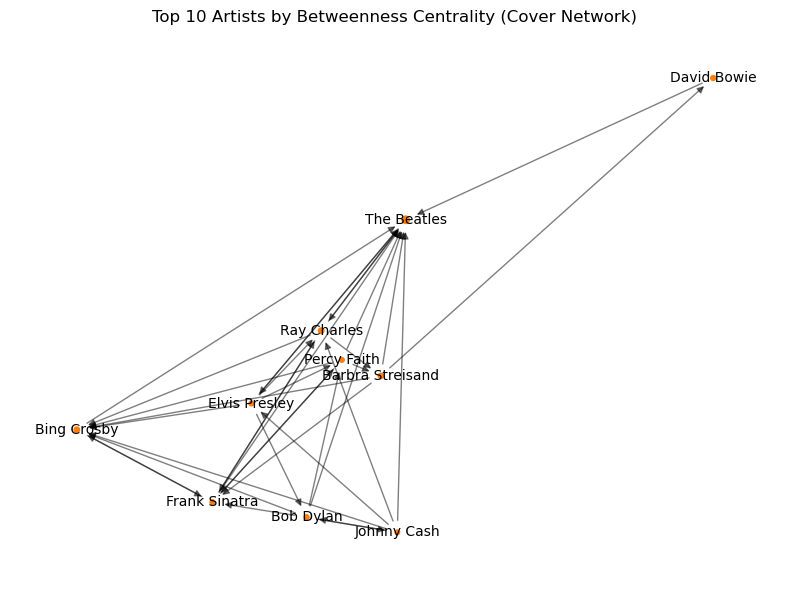

In [31]:
# Visualize only the top 10 Betweenness Centrality nodes and their edges in the cover network


# Get top 10 artist IDs by betweenness centrality
top_nodes = betweenness_cov_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_covered.subgraph(top_nodes).copy()

# Node colors: all orange
node_colors = ["#ff7f0e"] * len(G_top10.nodes())

# Node sizes: scale by betweenness centrality (for visual effect)
sizes = [betweenness_cov_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by Betweenness Centrality (Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

##### Layout algorithm: The spring_layout tries to minimize edge crossings and node overlap, but with only a few edges among the top 10, nodes with fewer direct connections will be pushed to the edge.
##### High betweenness in the full network does not guarantee a central position in a subgraph of only the top 10 nodes. The visualization reflects direct connections among those top 10, not their role in the entire network.

### Centrality metrics on wiki network

In [34]:
# In-degree centrality
in_deg_ment_scores = nx.in_degree_centrality(G_mentions)
in_deg_ment_df = top_metric_df(in_deg_ment_scores, G_mentions, 'in_degree_centrality')
in_deg_ment_df.round(4)

,artist_id,artist_name,in_degree_centrality
0,30607,Adele,0.1385
1,8358,Beyoncé,0.1328
2,297,U2,0.1286
3,224,Eminem,0.1125
4,84,Madonna,0.1115
5,211,Metallica,0.0908
6,223,Aerosmith,0.0862
7,10590,Coldplay,0.0858
8,19179,Rihanna,0.0855
9,1060,Bono,0.0801


In [60]:
# Save results to Excel file
within_path = os.path.join(project_root, "data", "results", "wiki.xlsx")
write_excel_sheet(within_path, "in_degree", in_deg_ment_df, index=True)

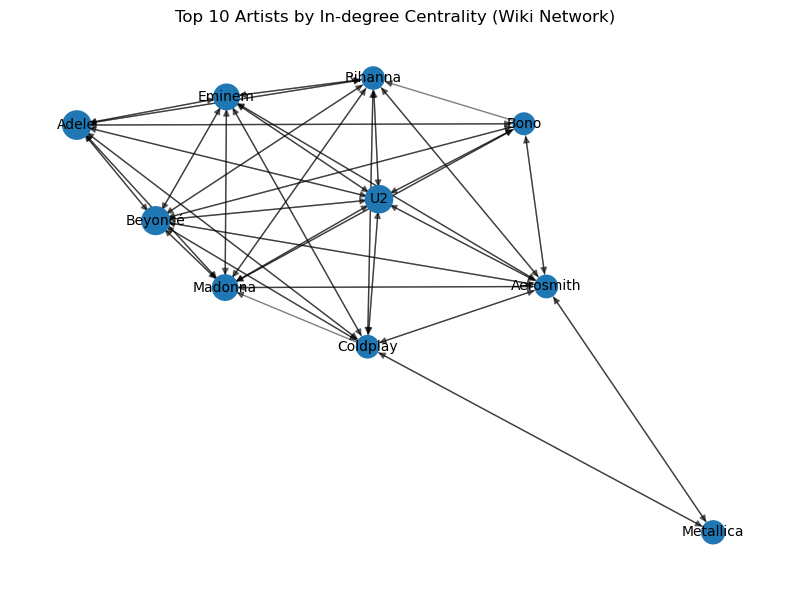

In [33]:
# Visualize only the top 10 in-degree centrality nodes and their edges in the wiki network

# Get top 10 artist IDs by in-degree centrality
top_nodes = in_deg_ment_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_mentions.subgraph(top_nodes).copy()

# Node colors: all blue
node_colors = ["#1f77b4"] * len(G_top10.nodes())

# Node sizes: scale by in-degree centrality (for visual effect)
sizes = [in_deg_ment_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_mentions.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by In-degree Centrality (Wiki Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [36]:
# PageRank
pagerank_ment_scores = nx.pagerank(G_mentions, alpha=0.85)  # no weights
pagerank_ment_df = top_metric_df(pagerank_ment_scores, G_mentions, 'pagerank_score')
pagerank_ment_df.round(4)

,artist_id,artist_name,pagerank_score
0,297,U2,0.0271
1,84,Madonna,0.0261
2,224,Eminem,0.0256
3,8358,Beyoncé,0.0255
4,10590,Coldplay,0.0238
5,223,Aerosmith,0.0234
6,211,Metallica,0.0230
7,30607,Adele,0.0213
8,19179,Rihanna,0.0213
9,248,Jay-Z,0.0207


In [61]:
# Save results to Excel file
within_path = os.path.join(project_root, "data", "results", "wiki.xlsx")
write_excel_sheet(within_path, "PageRank", pagerank_ment_df, index=True)

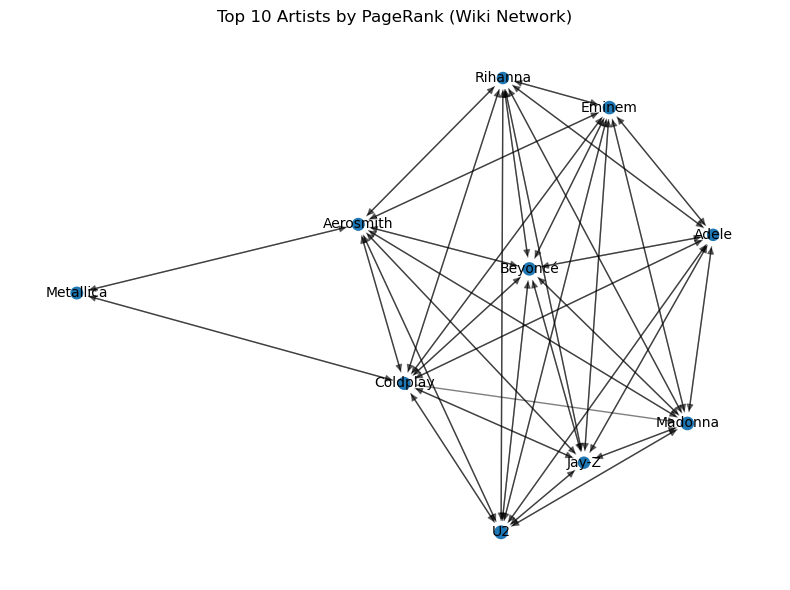

In [35]:
# Visualize only the top 10 PageRank nodes and their edges in the wiki network

# Get top 10 artist IDs by PageRank
top_nodes = pagerank_ment_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_mentions.subgraph(top_nodes).copy()

# Node colors: all blue
node_colors = ["#1f77b4"] * len(G_top10.nodes())

# Node sizes: scale by PageRank score (for visual effect)
sizes = [pagerank_ment_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_mentions.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by PageRank (Wiki Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [38]:
# Betweenness centrality
betweenness_ment_scores = nx.betweenness_centrality(G_mentions, k=100, seed=13)
betweenness_ment_df = top_metric_df(betweenness_ment_scores, G_mentions, 'betweenness_centrality')
betweenness_ment_df.round(4)

,artist_id,artist_name,betweenness_centrality
0,297,U2,0.0073
1,211,Metallica,0.0073
2,14508,Korn,0.0071
3,84,Madonna,0.0067
4,119,ABBA,0.0066
5,224,Eminem,0.0057
6,8358,Beyoncé,0.0057
7,10590,Coldplay,0.0057
8,223,Aerosmith,0.0046
9,13053,Björk,0.0043


In [62]:
# Save results to Excel file
within_path = os.path.join(project_root, "data", "results", "wiki.xlsx")
write_excel_sheet(within_path, "Betweenness", betweenness_ment_df, index=True)

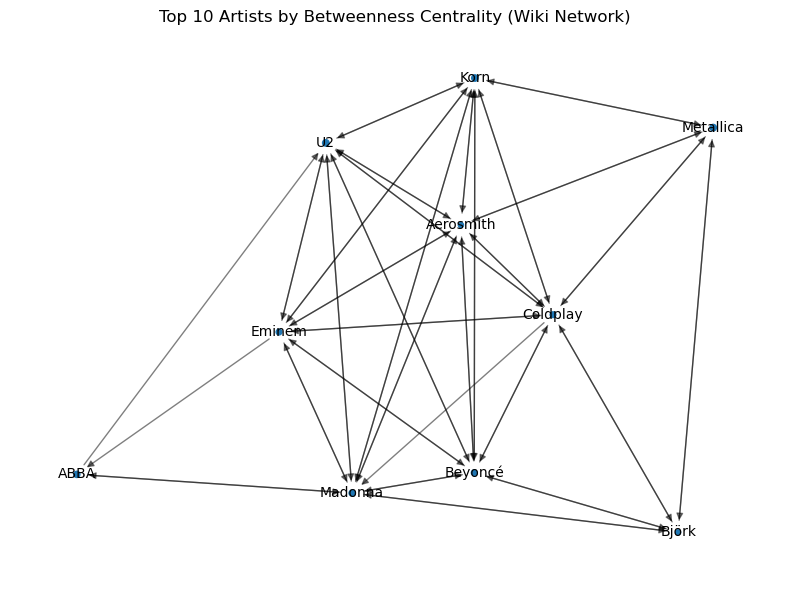

In [37]:
# Visualize only the top 10 Betweenness Centrality nodes and their edges in the wiki network
# Get top 10 artist IDs by betweenness centrality
top_nodes = betweenness_ment_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_mentions.subgraph(top_nodes).copy()

# Node colors: all blue
node_colors = ["#1f77b4"] * len(G_top10.nodes())

# Node sizes: scale by betweenness centrality (for visual effect)
sizes = [betweenness_ment_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_mentions.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by Betweenness Centrality (Wiki Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

### Centrality metrics on genre network

#### In-degree (within & cross genre)

In [68]:
# In-degree centrality
in_deg_within_scores = nx.in_degree_centrality(G_within)
in_deg_within_scores = top_metric_df(in_deg_within_scores, G_within, 'in_degree_centrality')
in_deg_within_scores.round(4)

,artist_id,artist_name,in_degree_centrality
0,41,The Beatles,0.1125
1,1424,Judy Garland,0.0319
2,14,The Beach Boys,0.0282
3,349,The Everly Brothers,0.0260
4,158,Bob Dylan,0.0231
5,380,The Kinks,0.0227
6,17,Led Zeppelin,0.0220
7,374,Queen,0.0220
8,934,Bruce Springsteen,0.0220
9,243,Bing Crosby,0.0194


In [48]:
# --- 1) Build within/cross subgraphs from G_covered ---
def make_within_cross_subgraphs(G, threshold=0.5, keep_all_nodes=False):
    edges_within, edges_cross = [], []
    for u, v, d in G.edges(data=True):
        gu = G.nodes[u].get('genres', [])
        gv = G.nodes[v].get('genres', [])
        if not gu or not gv:
            continue
        if genres_similar(gu, gv, threshold=threshold):
            edges_within.append((u, v))
        else:
            edges_cross.append((u, v))

    G_within = G.edge_subgraph(edges_within).copy()
    G_cross  = G.edge_subgraph(edges_cross).copy()

    if keep_all_nodes:
        Gw = nx.DiGraph(); Gw.add_nodes_from(G.nodes(data=True)); Gw.add_edges_from(G_within.edges(data=True))
        Gx = nx.DiGraph(); Gx.add_nodes_from(G.nodes(data=True)); Gx.add_edges_from(G_cross.edges(data=True))
        return Gw, Gx
    return G_within, G_cross

# choose whether to include all covered nodes (isolates) in the subgraphs for normalization
KEEP_ALL_NODES = False # Excluding isolates
G_within_graph, G_cross_graph = make_within_cross_subgraphs(G_covered, threshold=_similarity_threshold,
                                                            keep_all_nodes=KEEP_ALL_NODES)

# --- 2) Compute UNWEIGHTED in-degree centrality & absolute counts (within) ---
within_cent = nx.in_degree_centrality(G_within_graph)       # normalized by |V(sub)| - 1 (or all, if KEEP_ALL_NODES=True)
within_cnt  = dict(G_within_graph.in_degree())              # raw count of distinct within-genre coverers

within_top_df = top_metric_df(within_cent, G_covered, 'within_in_degree_centrality', top_n=10)
within_top_df['genres'] = within_top_df['artist_id'].map(lambda n: ", ".join(G_covered.nodes[n].get('genres', [])))
within_top_df['within_in_degree'] = within_top_df['artist_id'].map(within_cnt.get)

print("\nTop within-genre in-degree centrality (unweighted, within-edges only):")
print(within_top_df[['artist_id','artist_name','genres','within_in_degree_centrality','within_in_degree']]
      .round(4).to_string(index=False))

# --- 3) Compute UNWEIGHTED in-degree centrality & absolute counts (cross) ---
cross_cent = nx.in_degree_centrality(G_cross_graph)
cross_cnt  = dict(G_cross_graph.in_degree())

cross_top_df = top_metric_df(cross_cent, G_covered, 'cross_in_degree_centrality', top_n=10)
cross_top_df['genres'] = cross_top_df['artist_id'].map(lambda n: ", ".join(G_covered.nodes[n].get('genres', [])))
cross_top_df['cross_in_degree'] = cross_top_df['artist_id'].map(cross_cnt.get)

print("\nTop cross-genre in-degree centrality (unweighted, cross-edges only):")
print(cross_top_df[['artist_id','artist_name','genres','cross_in_degree_centrality','cross_in_degree']]
      .round(4).to_string(index=False))


Top within-genre in-degree centrality (unweighted, within-edges only):
 artist_id         artist_name                                  genres  within_in_degree_centrality  within_in_degree
        41         The Beatles                               rock, pop                       0.1125               307
      1424        Judy Garland                               pop, jazz                       0.0319                87
        14      The Beach Boys                               rock, pop                       0.0282                77
       349 The Everly Brothers                   rock, blues / country                       0.0260                71
       158           Bob Dylan folk, blues / country, rock, other, pop                       0.0231                63
       380           The Kinks                               rock, pop                       0.0227                62
        17        Led Zeppelin                             rock, metal                       0.0220   

In [41]:
# WITHIN genre
within_path = os.path.join(project_root, "data", "results", "within_genre.xlsx")
write_excel_sheet(within_path, "in_degree", within_top_df, index=True)

# CROSS genre
cross_path = os.path.join(project_root, "data", "results", "cross_genre.xlsx")
write_excel_sheet(cross_path, "in_degree", cross_top_df, index=True)

ModuleNotFoundError: No module named 'openpyxl'

##### In-degree visualization

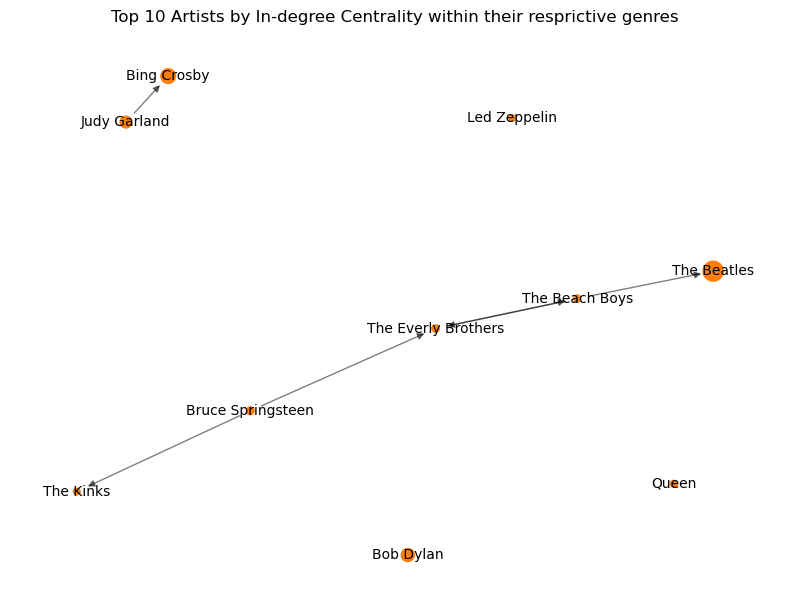

In [70]:
# Visualize only the top 10 in-degree centrality nodes and their edges in the cover network

# Get top 10 artist IDs by in-degree centrality
top_nodes = within_top_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_within.subgraph(top_nodes).copy()

# Node colors: all orange
node_colors = ["#ff7f0e"] * len(G_top10.nodes())

# Node sizes: scale by in-degree centrality (optional, for visual effect)
sizes = [in_deg_cov_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by In-degree Centrality within their resprictive genres")
plt.axis('off')
plt.tight_layout()
plt.show()

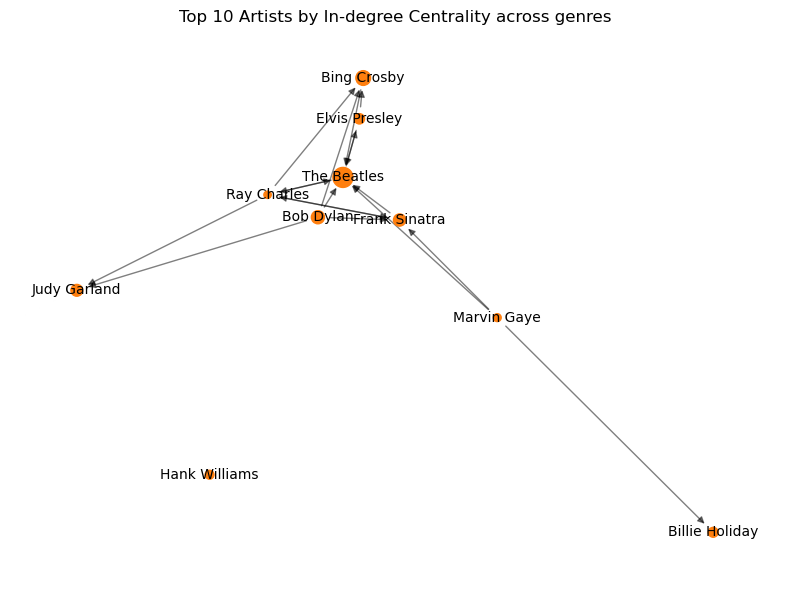

In [71]:
# Visualize only the top 10 in-degree centrality nodes and their edges in the cover network

# Get top 10 artist IDs by in-degree centrality
top_nodes = cross_top_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_cross.subgraph(top_nodes).copy()

# Node colors: all orange
node_colors = ["#ff7f0e"] * len(G_top10.nodes())

# Node sizes: scale by in-degree centrality (optional, for visual effect)
sizes = [in_deg_cov_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by In-degree Centrality across genres")
plt.axis('off')
plt.tight_layout()
plt.show()

#### PageRank (within & cross genre)

In [44]:
_topn = 10

def _add_genres(df):
    df['genres'] = df['artist_id'].map(lambda n: ", ".join(G_covered.nodes[n].get('genres', [])))
    return df

def _print_top(title, df, col):
    print(f"\n{title}")
    print(df[['artist_name', 'genres', col]].round(6).to_string(index=False))

# --- 1) Full-graph weighted PageRank (baseline) ---
pagerank_full = nx.pagerank(G_covered, alpha=0.85, weight='weight')
pr_full_df = top_metric_df(pagerank_full, G_covered, 'pagerank_full', top_n=_topn)
pr_full_df = _add_genres(pr_full_df)
_ = _print_top("Full-graph PageRank (weighted) — top:", pr_full_df, 'pagerank_full')

# --- 2) Within-genre-only weighted PageRank ---
pagerank_within = nx.pagerank(G_within_graph, alpha=0.85, weight='weight') if G_within_graph.number_of_edges() > 0 else {}
pr_within_df = top_metric_df(pagerank_within, G_covered, 'within_pagerank', top_n=_topn)
pr_within_df = _add_genres(pr_within_df)
_ = _print_top("Within-genre PageRank (edge-filter) — top:", pr_within_df, 'within_pagerank')

# --- 3) Cross-genre-only weighted PageRank ---
pagerank_cross = nx.pagerank(G_cross_graph, alpha=0.85, weight='weight') if G_cross_graph.number_of_edges() > 0 else {}
pr_cross_df = top_metric_df(pagerank_cross, G_covered, 'cross_pagerank', top_n=_topn)
pr_cross_df = _add_genres(pr_cross_df)
_ = _print_top("Cross-genre PageRank (edge-filter) — top:", pr_cross_df, 'cross_pagerank')


Full-graph PageRank (weighted) — top:
           artist_name                                         genres  pagerank_full
           The Beatles                                      rock, pop       0.012941
             Bob Dylan        folk, blues / country, rock, other, pop       0.005808
           Bing Crosby                               pop, jazz, other       0.003622
          Depeche Mode             electronic, rock, electronic, rock       0.003433
           Chuck Berry                                                      0.003406
        Duke Ellington                                                      0.003387
    The Rolling Stones                                                      0.003340
         Prince's Band                                                      0.003082
The Velvet Underground                                     rock, punk       0.002862
         Hank Williams blues / country, classical, world, other, rock       0.002777

Within-genre PageRank (ed

In [55]:
# WITHIN genre
within_path = os.path.join(project_root, "data", "results", "within_genre.xlsx")
write_excel_sheet(within_path, "PageRank", pr_within_df, index=True)


# CROSS genre
cross_path = os.path.join(project_root, "data", "results", "cross_genre.xlsx")
write_excel_sheet(cross_path, "PageRank", pr_cross_df, index=True)


#### Betweenness (within genre)

In [45]:
from math import inf

# ---- filters using your guarded rule ----
def _edge_is_within(G, u, v, thr):
    gu = G.nodes[u].get('genres', [])
    gv = G.nodes[v].get('genres', [])
    return bool(gu and gv and genres_similar(gu, gv, threshold=thr))

def _edge_is_cross(G, u, v, thr):
    gu = G.nodes[u].get('genres', [])
    gv = G.nodes[v].get('genres', [])
    return bool(gu and gv and not genres_similar(gu, gv, threshold=thr))

# ---- build undirected graph with optional weighting ----
def build_undirected_filtered_graph(G, edge_filter, threshold=0.5, use_weights=True):
    """
    Undirected graph where edges are included iff edge_filter(G,u,v,threshold) is True.
    - If use_weights: strength(u,v) = sum of directed weights u→v and v→u; length = 1/strength.
    - If not use_weights: all edges have unit length (unweighted shortest paths).
    """
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))

    # accumulate strengths if weighted
    if use_weights:
        for u, v, d in G.edges(data=True):
            if not edge_filter(G, u, v, threshold):
                continue
            w = d.get('weight', 1)
            if w <= 0:
                continue
            if H.has_edge(u, v):
                H[u][v]['strength'] += w
            else:
                H.add_edge(u, v, strength=w)

        # convert to distances
        for u, v, d in H.edges(data=True):
            s = d.get('strength', 0.0)
            d['length'] = (1.0 / s) if s > 0 else inf
    else:
        # unweighted: just add edges once
        seen = set()
        for u, v, d in G.edges(data=True):
            if not edge_filter(G, u, v, threshold):
                continue
            key = (min(u, v), max(u, v))
            if key in seen:
                continue
            seen.add(key)
            H.add_edge(u, v)  # no attributes

    return H

# ---- compute betweenness with optional sampling ----
def betweenness_top_df(H, graph_for_labels, col_name, top_n=10, k=100, seed=13, use_weights=True):
    if H.number_of_edges() == 0:
        return pd.DataFrame(columns=['artist_id','artist_name',col_name,'genres'])
    kk = None if k is None else min(k, H.number_of_nodes())
    weight_attr = 'length' if use_weights else None
    scores = nx.betweenness_centrality(H, weight=weight_attr, normalized=True, k=kk, seed=seed)
    df = top_metric_df(scores, graph_for_labels, col_name, top_n=top_n)
    df['genres'] = df['artist_id'].map(lambda n: ", ".join(graph_for_labels.nodes[n].get('genres', [])))
    return df

# ---- build within & cross graphs and compute top tables ----
thr = _similarity_threshold
USE_WEIGHTS = True  # set to False for unweighted shortest paths

H_within = build_undirected_filtered_graph(G_covered, _edge_is_within, threshold=thr, use_weights=USE_WEIGHTS)
H_cross  = build_undirected_filtered_graph(G_covered, _edge_is_cross,  threshold=thr, use_weights=USE_WEIGHTS)

_topn = 10
betw_within_df = betweenness_top_df(H_within, G_covered, 'betweenness_within', top_n=_topn, k=100, seed=13, use_weights=USE_WEIGHTS)
betw_cross_df  = betweenness_top_df(H_cross,  G_covered, 'betweenness_cross',  top_n=_topn, k=100, seed=13, use_weights=USE_WEIGHTS)

print("\n Top within-genre betweenness:".format("" if USE_WEIGHTS else "un"))
print(betw_within_df[['artist_id', 'artist_name','genres','betweenness_within']].round(6).to_string(index=False))

print("\nTop cross-genre betweenness:".format("" if USE_WEIGHTS else "un"))
print(betw_cross_df[['artist_id', 'artist_name','genres','betweenness_cross']].round(6).to_string(index=False))


 Top within-genre betweenness:
 artist_id    artist_name                            genres  betweenness_within
       279     Jack Jones                         pop, jazz            0.000482
        41    The Beatles                         rock, pop            0.000474
     11023     Diana Ross electronic, r&b & soul, pop, jazz            0.000412
      9717   Quincy Jones                  jazz, r&b & soul            0.000411
      1496 Billie Holiday        jazz, blues / country, pop            0.000281
      2682   Tony Bennett                  pop, jazz, other            0.000274
       319  Frank Sinatra                  pop, other, jazz            0.000259
      6872   Jimmy Dorsey                              jazz            0.000253
       243    Bing Crosby                  pop, jazz, other            0.000201
     30687     ApologetiX                       other, rock            0.000155

Top cross-genre betweenness:
 artist_id     artist_name                                

In [ ]:
# WITHIN genre
within_path = os.path.join(project_root, "data", "results", "within_genre.xlsx")
write_excel_sheet(within_path, "Betweenness", betw_within_df, index=True)

# CROSS genre
cross_path = os.path.join(project_root, "data", "results", "cross_genre.xlsx")
write_excel_sheet(cross_path, "Betweenness", betw_cross_df, index=True)

# ----- Can this be deleted below?

### Genre-specific centrality metrics - in progress


### The absolue network looks so ugly because our nodes are scaled (node size is proportional to the cross-genre covers) what we are basically seeing now are nodes (Green nodes, "#2ca02c" is green )

#### Participation Coefficient
measures how diversely an artist is covered across genre groups—i.e., boundary spanning versus being anchored in one scene. This is the standard participation coefficient from network cartography
--> from how many different genre camps is this artist being covered?

### old visualizations

In [ ]:
# Visualize top 10 cross-genre betweenness (absolute and normalized) in the cover network

# --- Absolute cross-genre betweenness ---
top_nodes_btw_abs = top_cross_btw_df['artist_id'].tolist()
G_top10_btw_abs = G_covered.subgraph(top_nodes_btw_abs).copy()
node_colors_btw_abs = ["#17becf"] * len(G_top10_btw_abs.nodes())  # cyan
sizes_btw_abs = [cross_genre_betweenness[n] * 30000 for n in G_top10_btw_abs.nodes()]  # scale for visibility

plt.figure(figsize=(8, 6))
pos_btw_abs = nx.spring_layout(G_top10_btw_abs, seed=42, k=0.5)
nx.draw_networkx_edges(G_top10_btw_abs, pos_btw_abs, alpha=0.5)
nx.draw_networkx_nodes(G_top10_btw_abs, pos_btw_abs, node_color=node_colors_btw_abs, node_size=sizes_btw_abs)
nx.draw_networkx_labels(
    G_top10_btw_abs, pos_btw_abs,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10_btw_abs.nodes()},
    font_size=10,
    font_color='black'
)
plt.title("Top 10 Artists by Cross-Genre Betweenness (Absolute, Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

# --- Normalized cross-genre betweenness ---
top_nodes_btw_norm = top_norm_cross_btw_df['artist_id'].tolist()
G_top10_btw_norm = G_covered.subgraph(top_nodes_btw_norm).copy()
node_colors_btw_norm = ["#bcbd22"] * len(G_top10_btw_norm.nodes())  # olive
sizes_btw_norm = [normalized_cross_genre_betweenness[n] * 3000 for n in G_top10_btw_norm.nodes()]  # scale for visibility

plt.figure(figsize=(8, 6))
pos_btw_norm = nx.spring_layout(G_top10_btw_norm, seed=42, k=0.5)
nx.draw_networkx_edges(G_top10_btw_norm, pos_btw_norm, alpha=0.5)
nx.draw_networkx_nodes(G_top10_btw_norm, pos_btw_norm, node_color=node_colors_btw_norm, node_size=sizes_btw_norm)
nx.draw_networkx_labels(
    G_top10_btw_norm, pos_btw_norm,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10_btw_norm.nodes()},
    font_size=10,
    font_color='black'
)
plt.title("Top 10 Artists by Normalized Cross-Genre Betweenness (Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

NameError: name 'top_cross_btw_df' is not defined

### Same problem as above, the numbers in the table are huge as well in comparison to the other tables where numbers are smaller than 1

## Example Subgraph

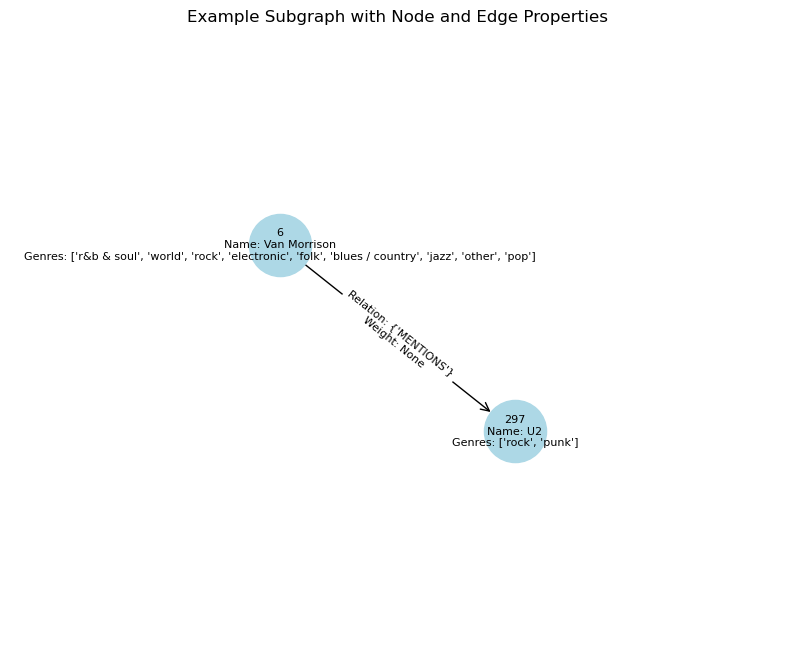

In [ ]:
# Pick one example edge (u, v) from G
u, v = list(G.edges())[0]  # take the first edge
edge_data = G.get_edge_data(u, v)

# Build subgraph with just these two nodes + the edge
H = nx.DiGraph()
H.add_node(u, **G.nodes[u])
H.add_node(v, **G.nodes[v])
H.add_edge(u, v, **edge_data)

# Layout
pos = nx.spring_layout(H, seed=42)

plt.figure(figsize=(10, 8))

# Draw nodes
nx.draw_networkx_nodes(H, pos, node_color="lightblue", node_size=2000)
nx.draw_networkx_edges(H, pos, arrowstyle="->",  node_size=2000, arrowsize=15)

# Node labels: show name + genres
node_labels = {n: f"{n}\nName: {H.nodes[n].get('name')}\nGenres: {H.nodes[n].get('genres')}" for n in H.nodes()}
nx.draw_networkx_labels(H, pos, labels=node_labels, font_size=8, font_color="black")

# Edge labels: show relation + weight
edge_labels = {(u, v): f"Relation: {edge_data.get('relation')}\nWeight: {edge_data.get('weight')}"}
nx.draw_networkx_edge_labels(H, pos, edge_labels=edge_labels, font_size=8)

plt.title("Example Subgraph with Node and Edge Properties")
plt.margins(1)
plt.axis("off")
plt.show()

## Overall averaged ranking

In [52]:
all_dfs = [
    in_deg_cov_df,
    pagerank_cov_df,
    betweenness_cov_df,
    in_deg_ment_df,
    pagerank_ment_df,
    betweenness_ment_df,
    within_top_df,
    cross_top_df,
    pr_within_df,
    pr_cross_df,
    betw_within_df,
    betw_cross_df
]
normalized_dfs = []

for i, df in enumerate(all_dfs, start=1):
    # Work on a copy so original df is untouched
    temp_df = df.copy()

    # Drop artist_id and genres if present
    temp_df = temp_df.drop(columns=[col for col in ["artist_id", "genres"] if col in temp_df.columns])

    # Pick the metric column (always index 2 after dropping)
    metric_col = temp_df.columns[2]

    # Normalize 0–1
    min_val = temp_df[metric_col].min()
    max_val = temp_df[metric_col].max()
    if max_val > min_val:
        temp_df["norm_score"] = (temp_df[metric_col] - min_val) / (max_val - min_val)
    else:
        temp_df["norm_score"] = 0  # fallback if all values are equal

    temp_df["source"] = f"df{i}"
    normalized_dfs.append(temp_df[["artist_name", "norm_score", "source"]])

# Combine everything
combined = pd.concat(normalized_dfs, ignore_index=True)

# Average normalized score across all measures
overall = (
    combined.groupby("artist_name")["norm_score"]
    .mean()
    .reset_index()
    .sort_values("norm_score", ascending=False)
    .reset_index(drop=True)
)

display(combined)
overall.round(4)

,artist_name,norm_score,source
0,The Beatles,1.000000,df1
1,Duke Ellington,0.336433,df1
2,Bing Crosby,0.324145,df1
3,Bob Dylan,0.156426,df1
4,Fred Astaire,0.134175,df1
...,...,...,...
115,Bob Dylan,0.332048,df12
116,Beegie Adair,0.306695,df12
117,Barbara Dickson,0.033221,df12
118,Chet Atkins,0.014782,df12


,artist_name,norm_score
0,Jack Jones,1.0000
1,The Beatles,0.9792
2,U2,0.9431
3,Korn,0.9248
4,Barry Manilow,0.8966
...,...,...
59,Marvin Gaye,0.0000
60,Franz Gruber,0.0000
61,Bono,0.0000
62,Little Richard,0.0000


In [53]:
# Get all unique artist names from all top-10s
all_artists = set()
for df in normalized_dfs:
    all_artists.update(df['artist_name'])

# Build a DataFrame with all combinations (artist, metric)
full_index = pd.MultiIndex.from_product([all_artists, range(1, len(normalized_dfs)+1)], names=['artist_name', 'source'])
full_df = pd.DataFrame(index=full_index).reset_index()

# Merge normalized scores
metric_map = {f'df{i}': i for i in range(1, len(normalized_dfs)+1)}
combined['source_num'] = combined['source'].map(metric_map)
full_df = full_df.merge(combined, left_on=['artist_name', 'source'], right_on=['artist_name', 'source_num'], how='left')

# Fill missing norm_score with 0
full_df['norm_score'] = full_df['norm_score'].fillna(0)

# Average normalized score across all 6 measures
overall_2 = (
    full_df.groupby("artist_name")["norm_score"]
    .mean()
    .reset_index()
    .sort_values("norm_score", ascending=False)
    .reset_index(drop=True)
)

overall_2.round(4).head(10)

,artist_name,norm_score
0,The Beatles,0.7344
1,U2,0.2358
2,Bing Crosby,0.2230
3,Bob Dylan,0.2082
4,Madonna,0.1812
5,Beyoncé,0.1758
6,Frank Sinatra,0.1655
7,Eminem,0.1499
8,Metallica,0.1280
9,Adele,0.0905
